![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/visual-nlp-workshop/blob/master/jupyter/SparkOcrWSIDeidentification.ipynb)

## Whole Slide Imaging De-identification

In this notebook, we will explore how to handle the de-identification of Whole Slide Imaging (WSI) files, specifically focusing on SVS files.</br>
We will cover:
* Removal of auxiliary images, like macro and label images.
* Removal of Metadata.
* Main image cleaning: in this situation we don't want to remove the entire image like the case of for example macro or label images, but we want to remove only specific regions which contain PHI. We want to do this keeping the quality of the original image intact. This process involves the following steps which we will discuss in next sections,
  * Look for text on a low resolution view of the whole slide
  * Find the PHI in that text
  * Black out those regions on every level of the source SVS file.

Let's jump right in!

### Introduction to the SVS file format

The SVS file format (commonly used for whole slide images (WSI) in digital pathology) is based on the TIFF format and supports multi-resolution (pyramidal) image storage. It allows storing extremely large images efficiently, along with metadata and multiple resolutions for fast zooming and viewing.
SVS typically stores images in a pyramid of resolutions,
* level 0 -> full resolution.
* level 1 -> downsampled version, like 1/4 of the resolution at level 0.
* ...
* level N -> more downsampling.

Something like this(image taken from nema.org),</br>
![sample wsi](https://dicom.nema.org/dicom/dicomwsi/sup145_fromword_files/image008.gif)

At each level, images are not stored as a single monolithic unit, but as a set of _tiles_. This enables for a more efficient handling of the image by viewers.</br>
Text found in the scanned area, like notes written with a pen on the glass or the edge of the slide label, is millimeters high: it is looked for on a low resolution view of the whole slide, and the regions found are then blacked out tile by tile on every level.

### Real World Example

In [ ]:
secret = ""
license = ""
aws_access_key = ""
aws_secret_key = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12"

### Initialization of spark session

In [1]:
from sparkocr import start
import os
import sys

if license:
    os.environ['JSL_OCR_LICENSE'] = license
    os.environ['SPARK_NLP_LICENSE'] = license

if aws_access_key:
    os.environ['AWS_ACCESS_KEY'] = aws_access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key

nlp_secret = ""

spark = start(secret=secret,
              jar_path=spark_ocr_jar_path, nlp_internal=True, nlp_secret=nlp_secret)

spark

### Removal of auxiliary images, like macro and label images, along with metadata.
First things first, before diving into the full resolution images, let's see how to remove the auxiliary images and the metadata. For this, the `svs.remove_phi()` comes handy. Let's take a look at the documentation,

In [1]:
from sparkocr.utils.svs.phi_cleaning import remove_phi
help(remove_phi)

Help on function remove_phi in module sparkocr.utils.svs.phi_cleaning:

remove_phi(input, output, tags=['ImageDescription.Filename', 'ImageDescription.Date', 'ImageDescription.Time', 'ImageDescription.User'], append_tags=[], rename=False, verbose=False, blocking=True)
    Remove label images, macro images, and specified metadata from SVS files.
    
    This function processes SVS files to remove sensitive metadata and associated images.
    By default, it removes specific metadata tags: "ImageDescription.Filename",
    "ImageDescription.Date", "ImageDescription.Time", and "ImageDescription.User".
    
    Parameters:
    - input (str): The file path or directory containing the SVS files to be de-identified.
    - output (str): The file path or directory where the de-identified files will be saved.
    - tags (list, optional): A list of metadata tags to remove, replacing the default tags if provided.
    - append_tags (list, optional): Additional tags to remove, added to the defaults w

So we see from the documentation that we can remove label, and macro images along with a predefined set of metadata tags. We can also add our own custom list of tags.</br>
We have everything we need, so let's do it!,

In [2]:
# make sure input files are in this folder
input_path = './data/wsi/wsi-sample.svs'
output_path = "deid_svs"

remove_phi(input_path, output_path, verbose=True)

de-identifying ./data/wsi/wsi-sample.svs
cleaned: label
cleaned: macro
cleaned tag field: ImageDescription.Filename
cleaned tag field: ImageDescription.Date
cleaned tag field: ImageDescription.Time
cleaned tag field: ImageDescription.User
Copied ./data/wsi/wsi-sample.svs as deid_svs/wsi-sample.svs


<Thread(Thread-6 (copy_and_strip_all), stopped 140147973682752)>

#### [optional] Tweaking additional parameters
You can safely skip this if you are good with the set of metadata tags that were removed.

In [3]:
input_path = './data/wsi/wsi-sample.svs'
output_path = "svs_output"

remove_phi(input_path, output_path, verbose=True, append_tags=['ImageDescription.ScanScope ID', 'ImageDescription.Time Zone', 'ImageDescription.ScannerType'])

de-identifying ./data/wsi/wsi-sample.svs
cleaned: label
cleaned: macro
cleaned tag field: ImageDescription.Filename
cleaned tag field: ImageDescription.Date
cleaned tag field: ImageDescription.Time
cleaned tag field: ImageDescription.User
Copied ./data/wsi/wsi-sample.svs as svs_output/wsi-sample.svs


<Thread(Thread-7 (copy_and_strip_all), stopped 140147973682752)>

#### Cleaning of the main image
The main image may contain text written on the glass. `text_image` reads the whole slide at a resolution given in microns per pixel (the slide's own resolution is taken from its metadata), from the closest pyramid level. This is the kind of view text is looked for in.

(250, 337, 3) level-0 pixels per view pixel: (16.023738872403563, 16.0)


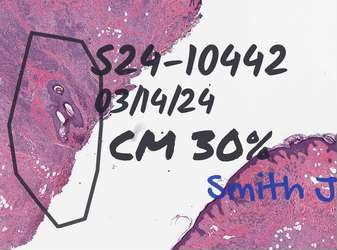

In [4]:
from PIL import Image
from sparkocr.utils.svs.deidentify import text_image

cleaned_svs = "deid_svs/wsi-sample.svs"
view, scale = text_image(cleaned_svs, 16)
print(view.shape, "level-0 pixels per view pixel:", scale)
Image.fromarray(view)

#### Text and PHI detection
`detect_phi_boxes` looks for text on a view like this one (16 microns per pixel by default). In `pipeline` mode (the default) each text region is read laid flat, whatever its direction, and the de-identification pipeline (OCR + NER) keeps only the PHI. The slide thumbnail is checked the same way. The boxes are returned in level-0 coordinates.

In [5]:
from sparkocr.pretrained import PretrainedPipeline
from sparkocr.utils.svs.deidentify import detect_phi_boxes

deid_pipeline = PretrainedPipeline("image_deid_multi_model_context_pipeline_cpu", "en", "clinical/ocr").model
boxes = detect_phi_boxes(cleaned_svs, mode="pipeline", deid_pipeline=deid_pipeline)
len(boxes)

image_deid_multi_model_context_pipeline_cpu download started this may take some time.


Approx size to download 4.9 GB
[ | ]

image_deid_multi_model_context_pipeline_cpu download started this may take some time.
Approximate size to download 4.9 GB


Download done! Loading the resource.


[OK!]

...

Using CPUs


Using CPUs


image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


13

#### Inspect the detected PHI
Let's draw the boxes found on the view of the slide,

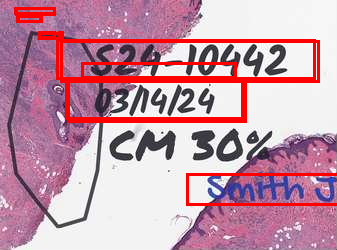

In [6]:
from PIL import ImageDraw

preview = Image.fromarray(view)
draw = ImageDraw.Draw(preview)
for x1, y1, x2, y2 in boxes:
    draw.rectangle([x1 / scale[0], y1 / scale[1], x2 / scale[0], y2 / scale[1]], outline=(255, 0, 0), width=3)
preview

#### Masking of the regions in the SVS
`redact_boxes` blacks out the boxes on every pyramid level and on the thumbnail. By default only the tiles they touch are rewritten, in place; `create_new_svs_file=True` writes a new file instead.

21:31:57, INFO Starting deidentification on SVS: svs_deid/wsi-sample.svs


21:31:57, INFO Total pages in SVS: 4


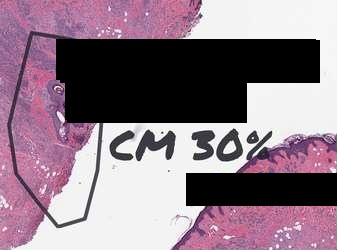

In [7]:
!mkdir -p svs_deid && cp deid_svs/wsi-sample.svs svs_deid/
from sparkocr.utils.svs.deidentify import redact_boxes

redact_boxes("svs_deid/wsi-sample.svs", boxes)
view_deid, _ = text_image("svs_deid/wsi-sample.svs", 16)
Image.fromarray(view_deid)

### All in one: `deidentify_svs`
`deidentify_svs` runs every step above on one file (associated images and metadata, text detection, redaction) and writes the result, leaving the input untouched.

In [8]:
from sparkocr.utils.svs.deidentify import deidentify_svs

deidentify_svs("./data/wsi/wsi-sample.svs", "deid_svs_pipeline/wsi-sample.svs", deid_pipeline=deid_pipeline)

image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


21:32:32, INFO Starting deidentification on SVS: /tmp/svs_deid_24439gi6/cleaned/wsi-sample.svs


21:32:32, INFO Total pages in SVS: 4


'deid_svs_pipeline/wsi-sample.svs'

### Mode 2: blanket de-identification
Instead of running the PHI pipeline, every text region found by the text detector is redacted, notes that aren't PHI included. No de-identification pipeline is loaded, so it only needs the Spark session started above.

image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


image_text_detector_mem_opt download started this may take some time.
Approximate size to download 77.5 MB


21:32:40, INFO Starting deidentification on SVS: /tmp/svs_deid_ym2ahj8p/cleaned/wsi-sample.svs


21:32:40, INFO Total pages in SVS: 4


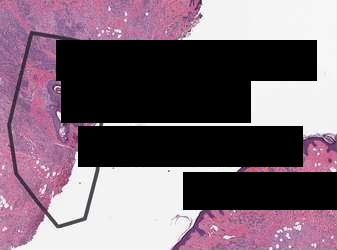

In [9]:
deidentify_svs("./data/wsi/wsi-sample.svs", "deid_svs_blanket/wsi-sample.svs", mode="blanket")
view_blanket, _ = text_image("deid_svs_blanket/wsi-sample.svs", 16)
Image.fromarray(view_blanket)